# t-SNE (t-Distributed Stochastic Neighbor Embedding)

## Overview
t-SNE is a **non-linear dimensionality reduction** technique designed for
**visualization** of high-dimensional data in 2D or 3D.
It preserves **local structure** — nearby points stay nearby in the low-dimensional map.

### Key Parameters:
| Parameter | Role |
|-----------|------|
| `perplexity` | Effective number of neighbors (5-50 typical) |
| `max_iter` | Optimization iterations (1000 recommended) |
| `learning_rate` | Gradient step (auto recommended) |
| `init` | pca (stable) or random |

---
### Topics Covered
1. Imports & version-safe setup
2. t-SNE vs PCA — Swiss Roll
3. Effect of perplexity
4. Effect of iterations
5. Multi-class data
6. PCA init vs random init
7. Synthetic image data
8. Cluster validation
9. Real-world offline-safe dataset
10. Limitations and best practices


## 1. Import Libraries & Version-Safe Setup

In [1]:
import os
# Fix joblib CPU detection error in virtual environments
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_classification, make_swiss_roll
from sklearn.metrics import silhouette_score

# Version-safe iteration parameter
# sklearn >= 1.5 renamed n_iter -> max_iter in TSNE
sk_ver = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
ITER_KEY = 'max_iter' if sk_ver >= (1, 5) else 'n_iter'

def make_tsne(n_components=2, perplexity=30, n_iterations=1000,
              random_state=42, init='pca'):
    """Version-safe TSNE constructor."""
    return TSNE(
        n_components=n_components,
        perplexity=perplexity,
        random_state=random_state,
        init=init,
        **{ITER_KEY: n_iterations}
    )

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}
CLUSTER_COLORS = ['#E74C3C','#2E86AB','#27AE60','#E67E22',
                  '#9B59B6','#F39C12','#1ABC9C','#E91E63']

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print(f'sklearn version : {sklearn.__version__}')
print(f'TSNE iter param : {ITER_KEY}')
print(f'NumPy           : {np.__version__}')
print(f'Pandas          : {pd.__version__}')
print('All libraries ready!')

sklearn version : 1.7.2
TSNE iter param : max_iter
NumPy           : 1.26.4
Pandas          : 2.3.3
All libraries ready!


## 2. t-SNE vs PCA — Swiss Roll (Local vs Global Structure)

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


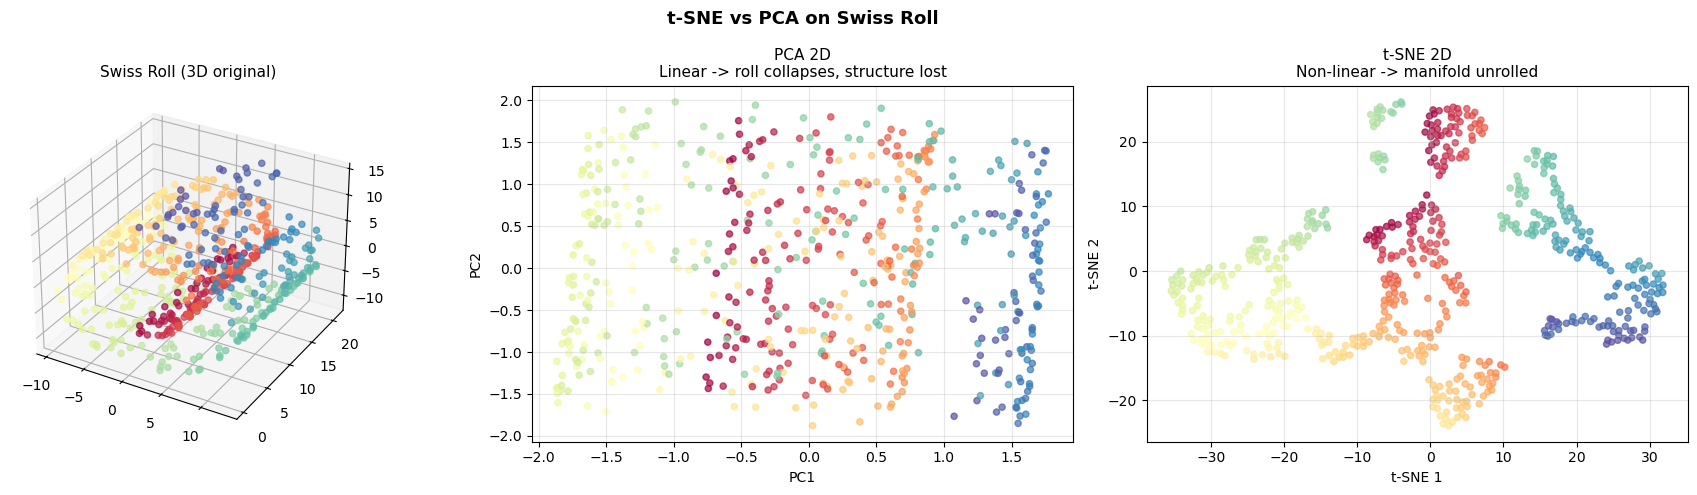

PCA  : linear projection -> nearby points on different rolls mix together
t-SNE: preserves local neighborhoods -> continuous color gradient visible


In [2]:
np.random.seed(42)
X_sw, color_sw = make_swiss_roll(n_samples=600, noise=0.1, random_state=42)
X_sw_sc = StandardScaler().fit_transform(X_sw)

pca_sw    = PCA(n_components=2)
X_pca_sw  = pca_sw.fit_transform(X_sw_sc)

X_tsne_sw = make_tsne(perplexity=30, n_iterations=1000).fit_transform(X_sw_sc)

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_sw[:,0], X_sw[:,1], X_sw[:,2],
            c=color_sw, cmap='Spectral', s=20, alpha=0.7)
ax1.set_title('Swiss Roll (3D original)', fontsize=11)

ax2 = fig.add_subplot(132)
ax2.scatter(X_pca_sw[:,0], X_pca_sw[:,1],
            c=color_sw, cmap='Spectral', s=20, alpha=0.7)
ax2.set_title('PCA 2D\nLinear -> roll collapses, structure lost', fontsize=11)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

ax3 = fig.add_subplot(133)
ax3.scatter(X_tsne_sw[:,0], X_tsne_sw[:,1],
            c=color_sw, cmap='Spectral', s=20, alpha=0.7)
ax3.set_title('t-SNE 2D\nNon-linear -> manifold unrolled', fontsize=11)
ax3.set_xlabel('t-SNE 1'); ax3.set_ylabel('t-SNE 2')

plt.suptitle('t-SNE vs PCA on Swiss Roll', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('PCA  : linear projection -> nearby points on different rolls mix together')
print('t-SNE: preserves local neighborhoods -> continuous color gradient visible')

## 3. Effect of Perplexity

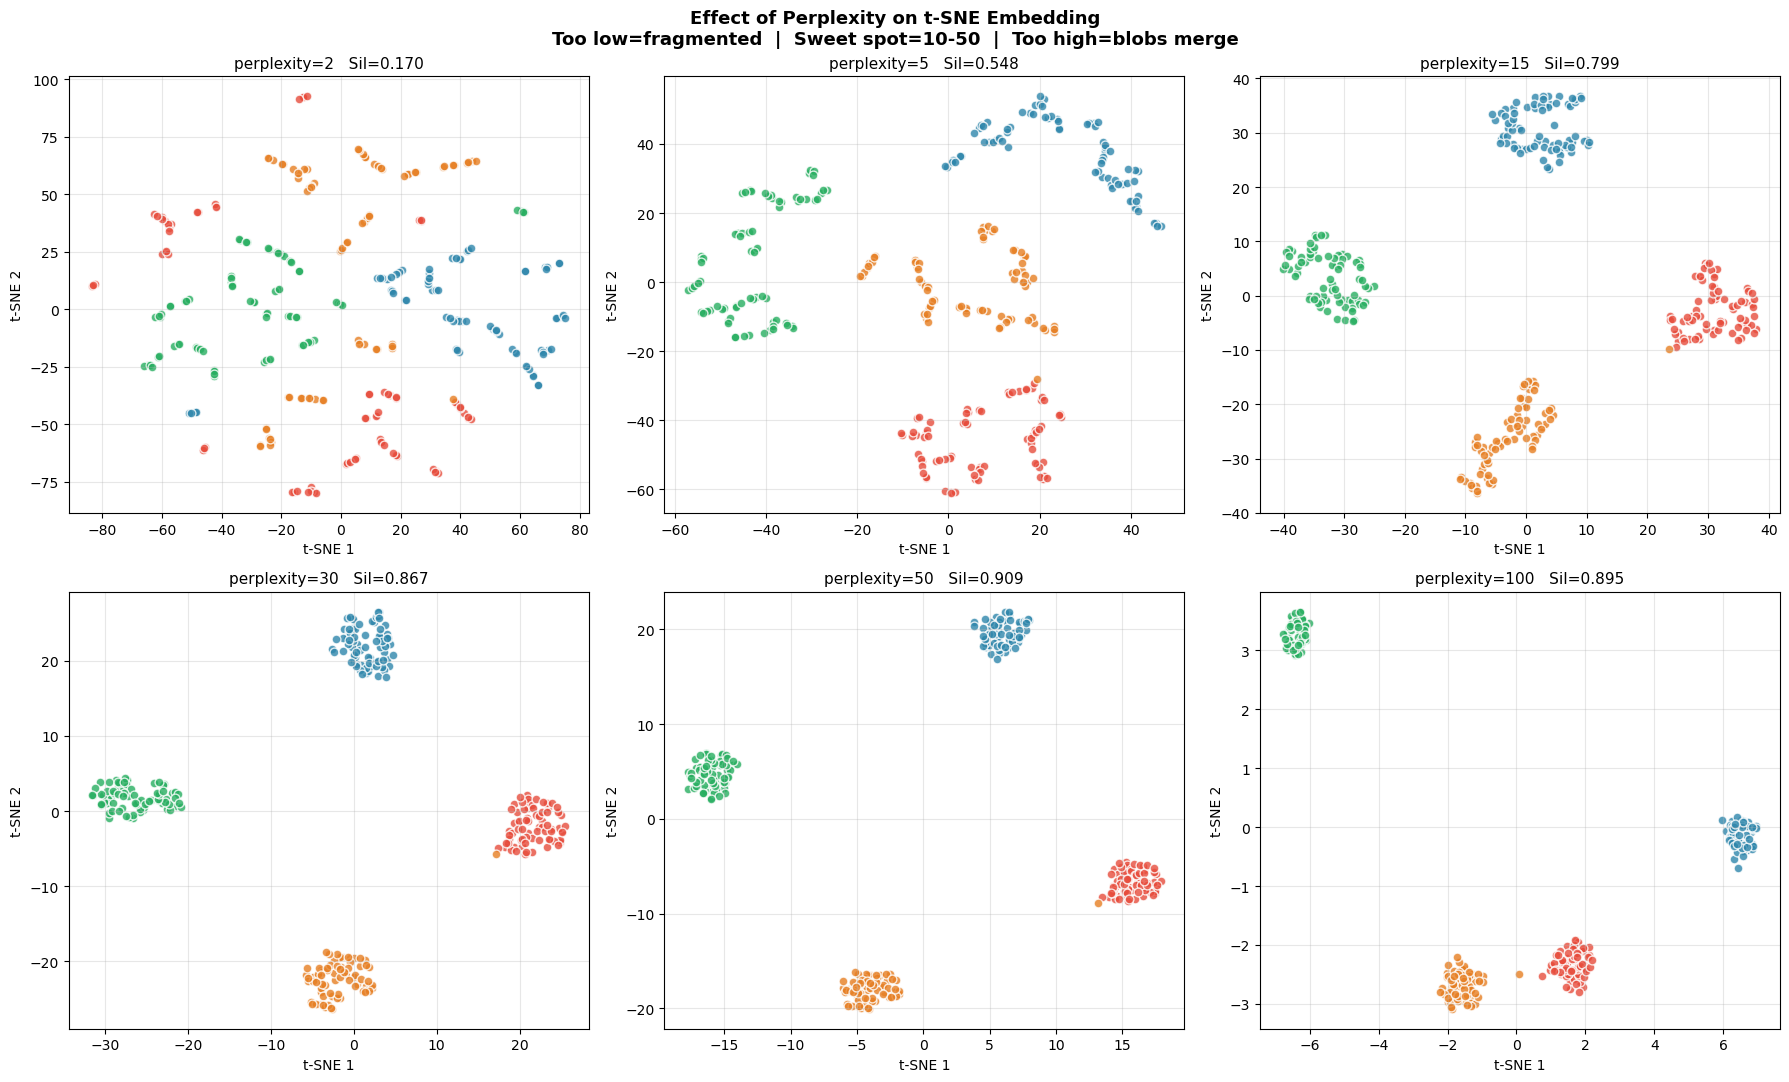

Too low  (2-5)  -> local noise dominates, fragmented clusters
Ideal   (15-50) -> balanced local/global structure
Too high (100+) -> global distances distorted
Rule of thumb   -> perplexity < n_samples / 3


In [3]:
np.random.seed(42)
X_p, y_p = make_blobs(n_samples=300, centers=4,
                       cluster_std=1.0, random_state=42)
X_p_sc = StandardScaler().fit_transform(X_p)

perplexities = [2, 5, 15, 30, 50, 100]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, perp in zip(axes, perplexities):
    X_emb = make_tsne(perplexity=perp, n_iterations=1000).fit_transform(X_p_sc)
    sil   = silhouette_score(X_emb, y_p)
    for k in np.unique(y_p):
        mask = y_p == k
        ax.scatter(X_emb[mask,0], X_emb[mask,1],
                   color=CLUSTER_COLORS[k], s=40, alpha=0.8,
                   edgecolors='white')
    ax.set_title(f'perplexity={perp}   Sil={sil:.3f}', fontsize=11)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.suptitle('Effect of Perplexity on t-SNE Embedding\n'
             'Too low=fragmented  |  Sweet spot=10-50  |  Too high=blobs merge',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Too low  (2-5)  -> local noise dominates, fragmented clusters')
print('Ideal   (15-50) -> balanced local/global structure')
print('Too high (100+) -> global distances distorted')
print('Rule of thumb   -> perplexity < n_samples / 3')

## 4. Effect of Iterations (Convergence)

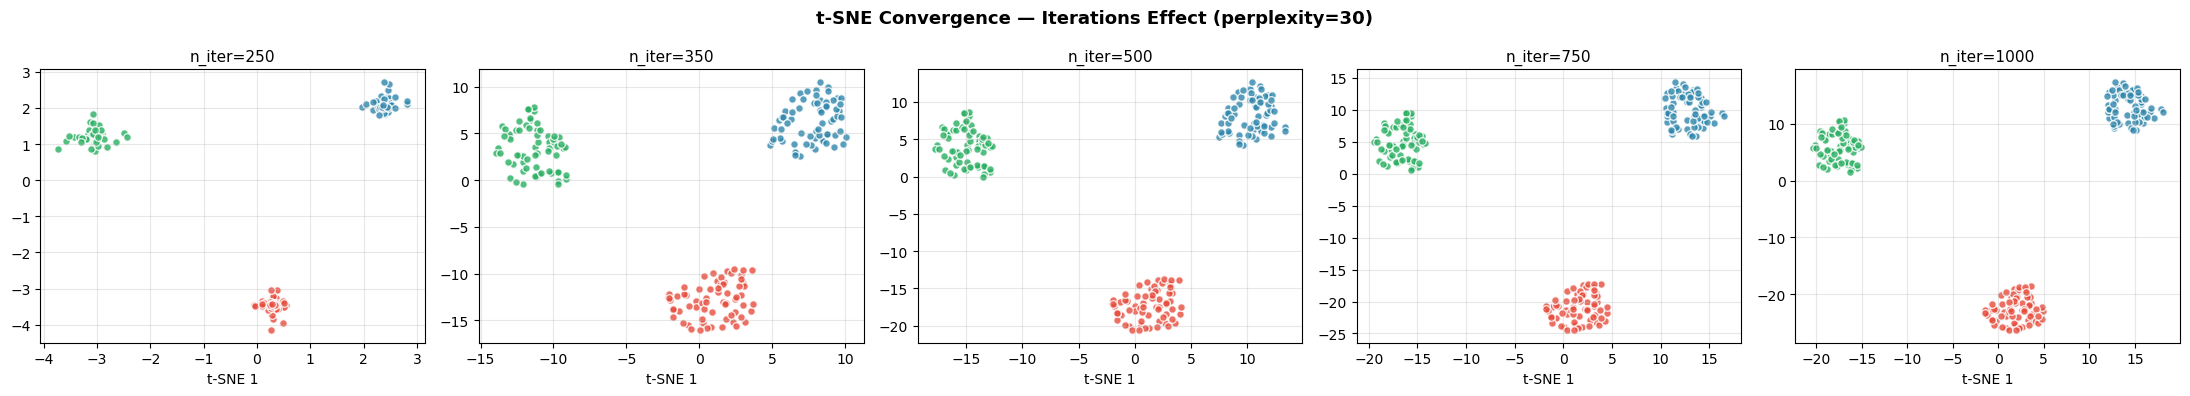

sklearn >= 1.5 enforces max_iter >= 250 (minimum for convergence)
250  -> early stage, clusters forming
500  -> mostly converged
1000 -> fully converged, safe default


In [5]:
np.random.seed(42)
X_it, y_it = make_blobs(n_samples=200, centers=3,
                         cluster_std=0.8, random_state=42)
X_it_sc = StandardScaler().fit_transform(X_it)

# min value for max_iter in sklearn >= 1.5 is 250
iter_values = [250, 350, 500, 750, 1000]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, n_it in zip(axes, iter_values):
    X_emb = make_tsne(perplexity=30, n_iterations=n_it).fit_transform(X_it_sc)
    for k in np.unique(y_it):
        mask = y_it == k
        ax.scatter(X_emb[mask,0], X_emb[mask,1],
                   color=CLUSTER_COLORS[k], s=30,
                   alpha=0.8, edgecolors='white')
    ax.set_title(f'n_iter={n_it}', fontsize=11)
    ax.set_xlabel('t-SNE 1')

plt.suptitle('t-SNE Convergence — Iterations Effect (perplexity=30)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('sklearn >= 1.5 enforces max_iter >= 250 (minimum for convergence)')
print('250  -> early stage, clusters forming')
print('500  -> mostly converged')
print('1000 -> fully converged, safe default')

## 5. t-SNE on Multi-Class Data

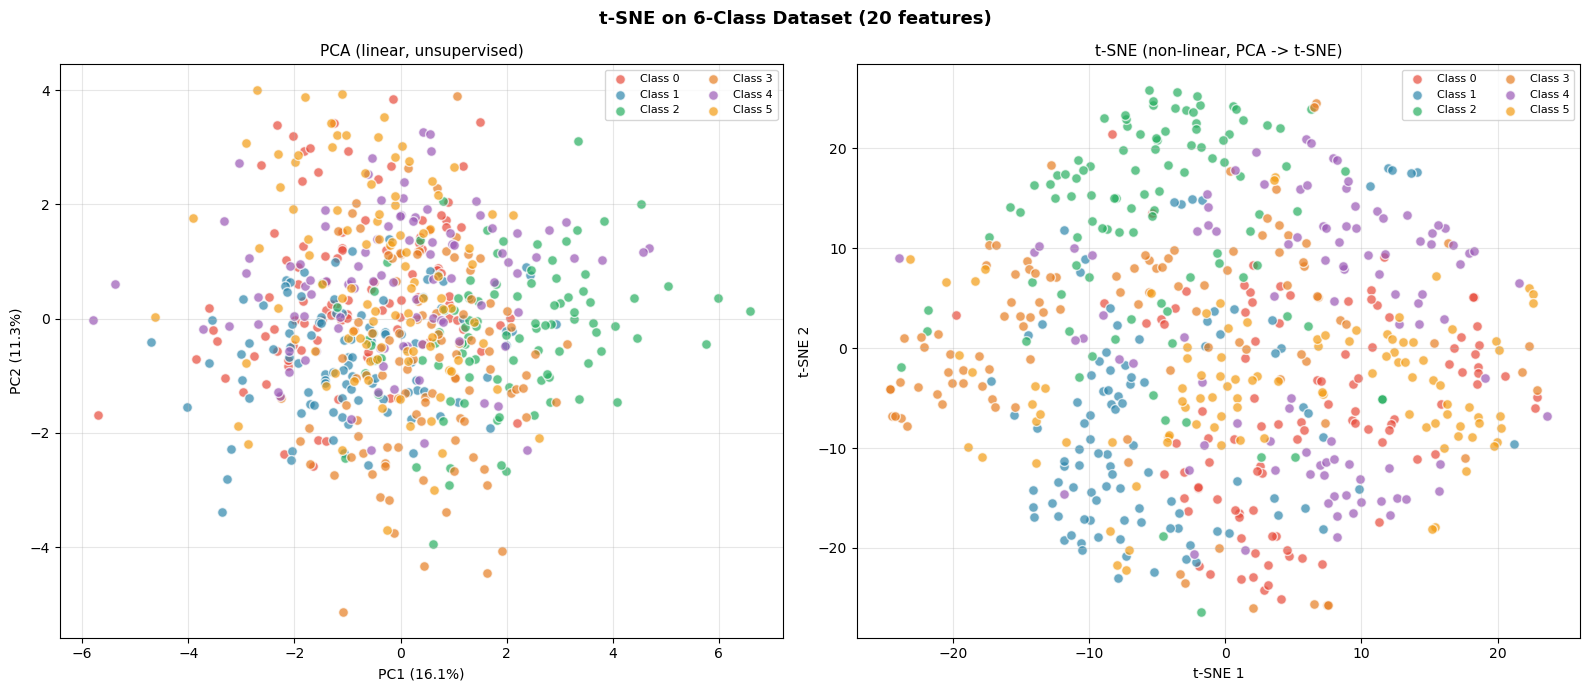

Best practice: PCA to ~10-50 dims first, then t-SNE
This speeds up t-SNE significantly with no quality loss.


In [6]:
np.random.seed(42)
n_cls = 6
X_mc, y_mc = make_classification(
    n_samples=600, n_features=20, n_informative=15,
    n_redundant=3, n_classes=n_cls, n_clusters_per_class=1,
    random_state=42
)
X_mc_sc = StandardScaler().fit_transform(X_mc)

# PCA first for speed — recommended best practice
X_mc_pca10 = PCA(n_components=10, random_state=42).fit_transform(X_mc_sc)
X_mc_tsne  = make_tsne(perplexity=30, n_iterations=1000).fit_transform(X_mc_pca10)

pca_mc2   = PCA(n_components=2)
X_mc_pca2 = pca_mc2.fit_transform(X_mc_sc)
evr_mc    = pca_mc2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, X_2d, title, xl, yl in zip(
    axes,
    [X_mc_pca2, X_mc_tsne],
    ['PCA (linear, unsupervised)',
     't-SNE (non-linear, PCA -> t-SNE)'],
    [f'PC1 ({evr_mc[0]*100:.1f}%)', 't-SNE 1'],
    [f'PC2 ({evr_mc[1]*100:.1f}%)', 't-SNE 2']
):
    for k in range(n_cls):
        mask = y_mc == k
        ax.scatter(X_2d[mask,0], X_2d[mask,1],
                   color=CLUSTER_COLORS[k], s=50, alpha=0.7,
                   edgecolors='white', label=f'Class {k}')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle(f't-SNE on {n_cls}-Class Dataset (20 features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Best practice: PCA to ~10-50 dims first, then t-SNE')
print('This speeds up t-SNE significantly with no quality loss.')

## 6. PCA Init vs Random Init

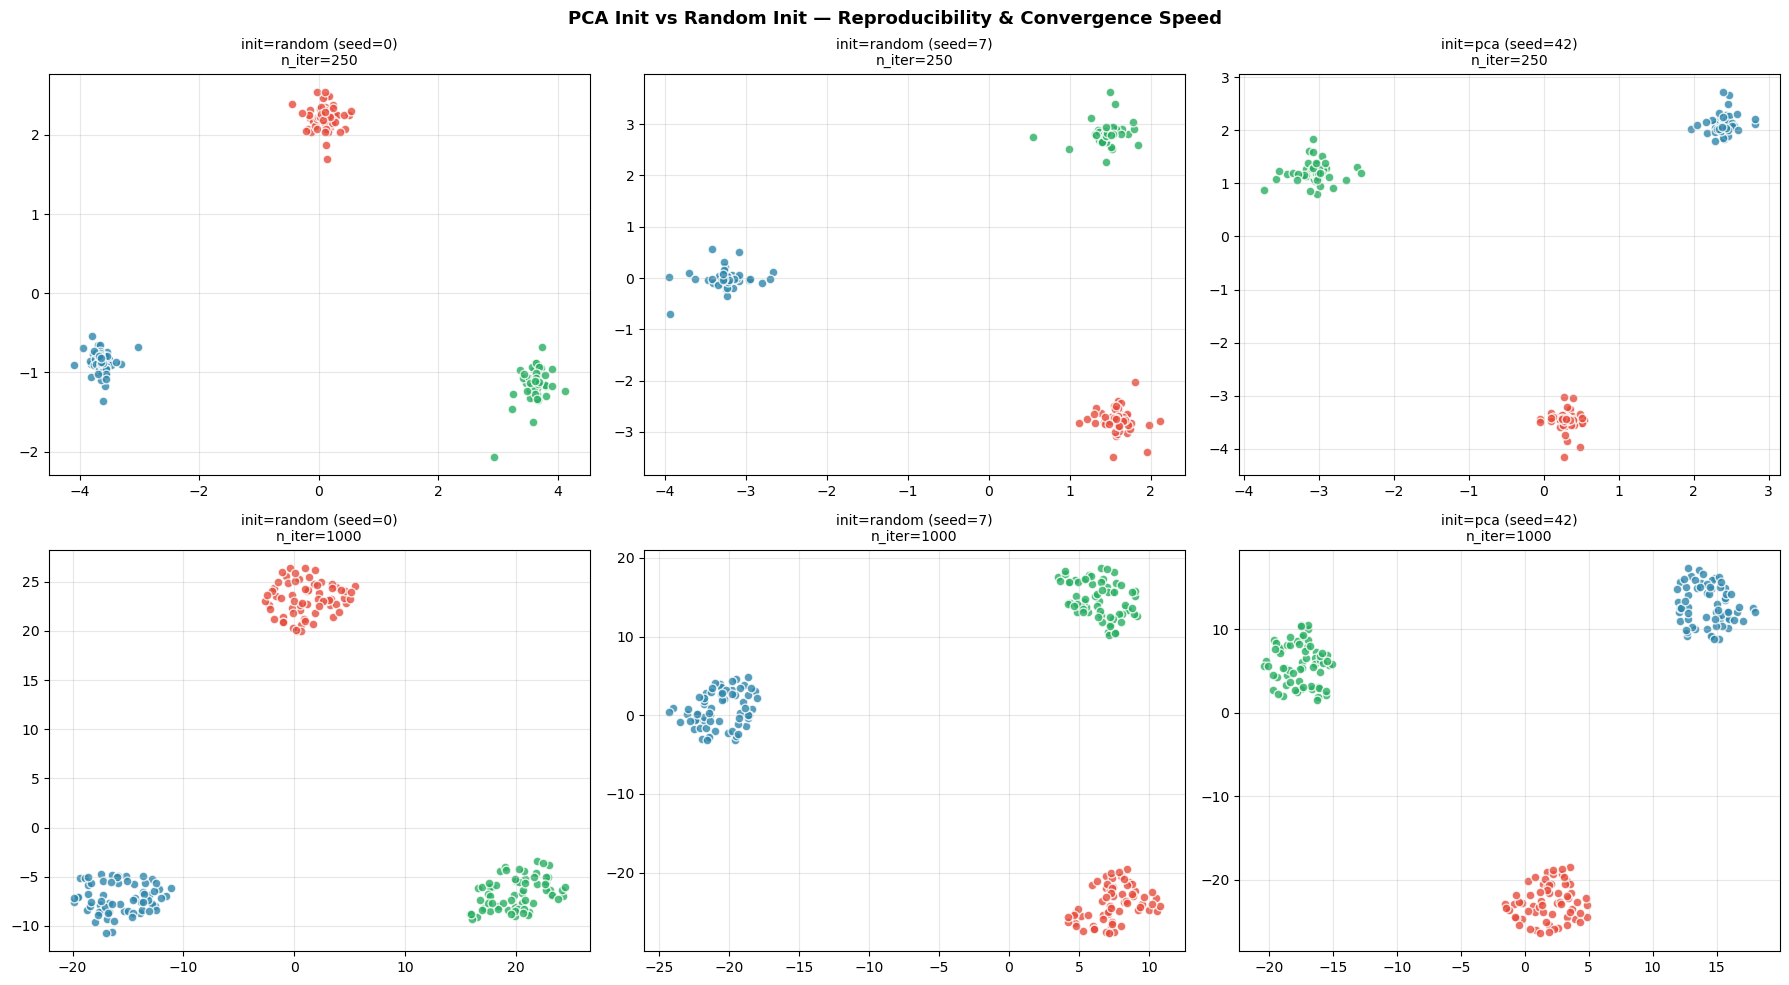

Random init: results differ across seeds (rotation/reflection)
PCA init   : deterministic start -> faster convergence, more stable
Use init="pca" for reproducible results.


In [7]:
np.random.seed(42)
X_in, y_in = make_blobs(n_samples=200, centers=3,
                         cluster_std=0.8, random_state=42)
X_in_sc = StandardScaler().fit_transform(X_in)

configs = [
    ('random', 0),
    ('random', 7),
    ('pca',    42),
]
iter_vals = [250, 1000]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (init_type, seed) in enumerate(configs):
    for row, n_it in enumerate(iter_vals):
        X_emb = make_tsne(
            perplexity=30, n_iterations=n_it,
            random_state=seed, init=init_type
        ).fit_transform(X_in_sc)
        ax = axes[row][col]
        for k in np.unique(y_in):
            mask = y_in == k
            ax.scatter(X_emb[mask,0], X_emb[mask,1],
                       color=CLUSTER_COLORS[k], s=40,
                       alpha=0.8, edgecolors='white')
        ax.set_title(
            f'init={init_type} (seed={seed})\nn_iter={n_it}',
            fontsize=10
        )

plt.suptitle('PCA Init vs Random Init — Reproducibility & Convergence Speed',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Random init: results differ across seeds (rotation/reflection)')
print('PCA init   : deterministic start -> faster convergence, more stable')
print('Use init="pca" for reproducible results.')

## 7. t-SNE on Synthetic Image Data

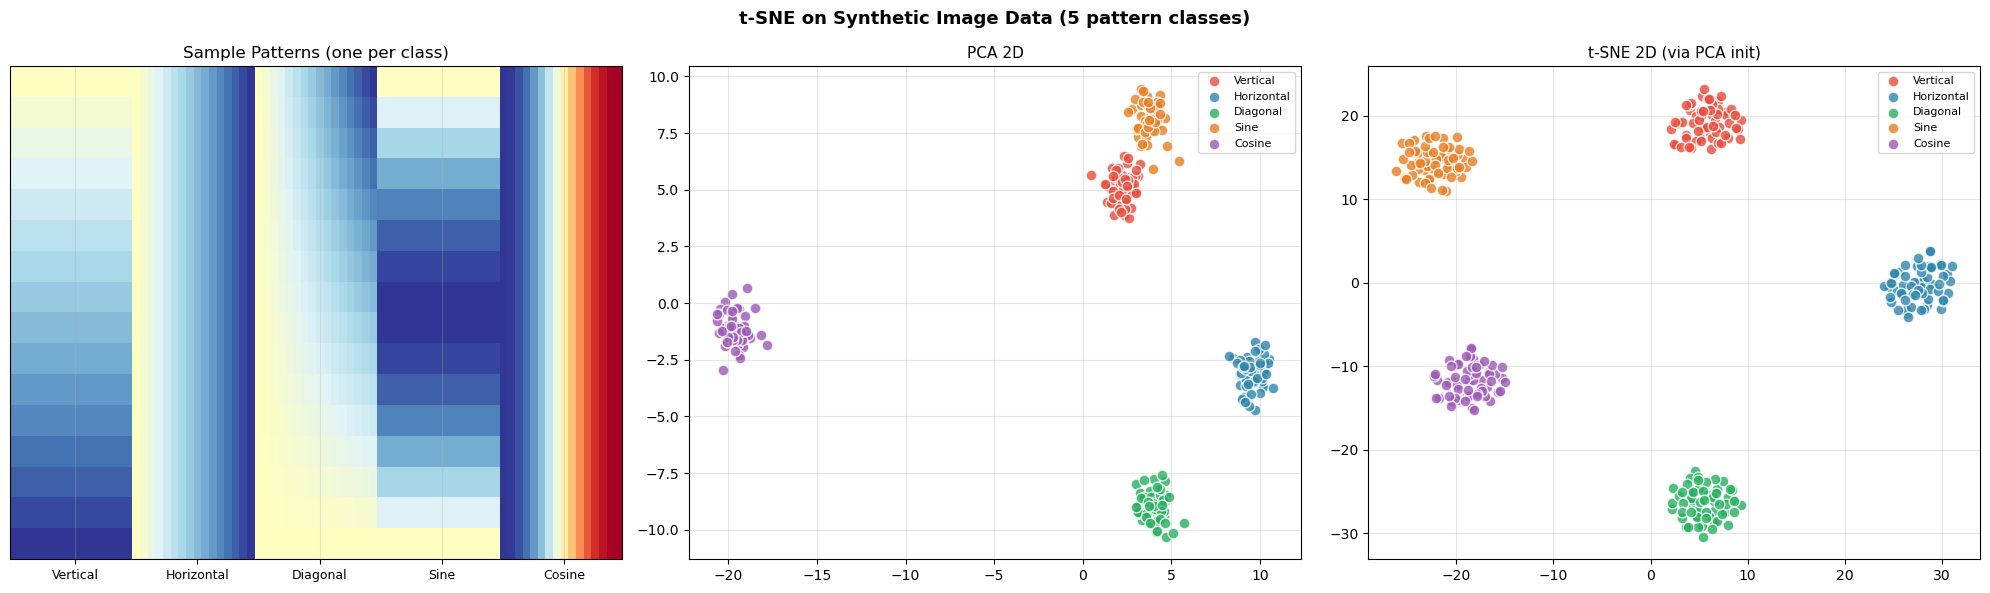

In [8]:
np.random.seed(42)
H, W = 16, 16
n_per = 60
n_cls_img = 5

patterns = [
    np.outer(np.linspace(0,1,H), np.ones(W)),
    np.outer(np.ones(H), np.linspace(0,1,W)),
    np.outer(np.linspace(1,0,H), np.linspace(0,1,W)),
    np.sin(np.outer(np.linspace(0,np.pi,H), np.ones(W))),
    np.cos(np.outer(np.ones(H), np.linspace(0,np.pi,W))),
]
class_names = ['Vertical','Horizontal','Diagonal','Sine','Cosine']

X_img_list, y_img_list = [], []
for k, pat in enumerate(patterns):
    imgs = pat + np.random.randn(n_per, H, W) * 0.3
    X_img_list.append(imgs.reshape(n_per, H*W))
    y_img_list.extend([k]*n_per)

X_img    = np.vstack(X_img_list)
y_img    = np.array(y_img_list)
X_img_sc = StandardScaler().fit_transform(X_img)

X_img_pca20 = PCA(n_components=20, random_state=42).fit_transform(X_img_sc)
X_img_tsne  = make_tsne(perplexity=20, n_iterations=1000).fit_transform(X_img_pca20)
X_img_pca2  = PCA(n_components=2).fit_transform(X_img_sc)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Sample patterns
grid = np.hstack([p for p in patterns])
axes[0].imshow(grid, cmap='RdYlBu', aspect='auto')
axes[0].set_title('Sample Patterns (one per class)')
axes[0].set_xticks([(k+0.5)*W for k in range(n_cls_img)])
axes[0].set_xticklabels(class_names, fontsize=9)
axes[0].set_yticks([])

for ax, X_2d, title in zip(
    axes[1:],
    [X_img_pca2, X_img_tsne],
    ['PCA 2D', 't-SNE 2D (via PCA init)']
):
    for k in range(n_cls_img):
        mask = y_img == k
        ax.scatter(X_2d[mask,0], X_2d[mask,1],
                   color=CLUSTER_COLORS[k], s=60, alpha=0.8,
                   edgecolors='white', label=class_names[k])
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('t-SNE on Synthetic Image Data (5 pattern classes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. t-SNE for Cluster Validation

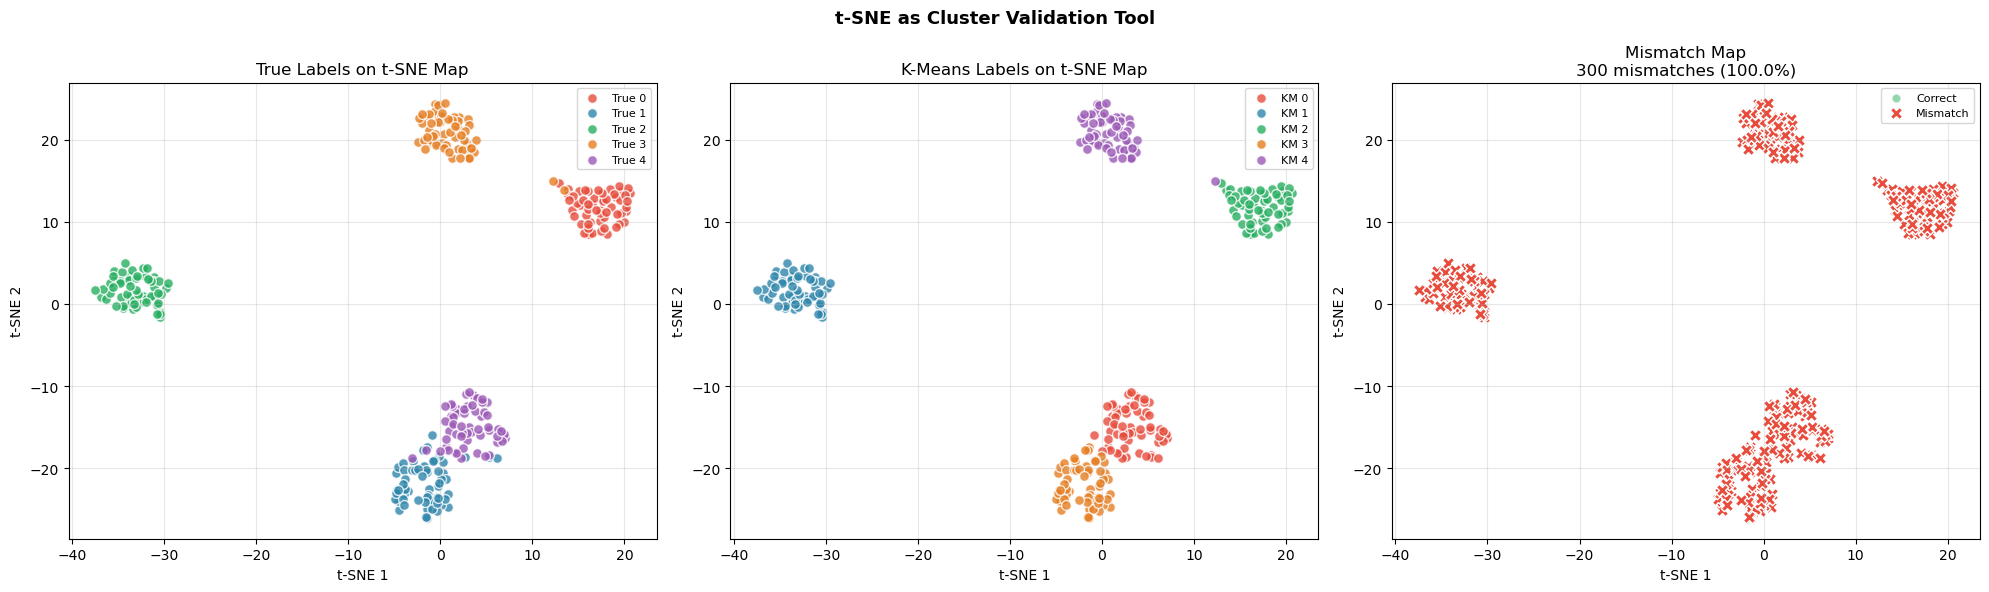

K-Means Silhouette : 0.6041
Mismatches         : 300 / 300


In [9]:
np.random.seed(42)
X_val, y_val = make_blobs(n_samples=300, centers=5,
                           cluster_std=1.2, random_state=42)
X_val_sc = StandardScaler().fit_transform(X_val)

km_val    = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
km_labels = km_val.fit_predict(X_val_sc)

X_val_tsne = make_tsne(perplexity=30, n_iterations=1000).fit_transform(X_val_sc)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for k in np.unique(y_val):
    mask = y_val == k
    axes[0].scatter(X_val_tsne[mask,0], X_val_tsne[mask,1],
                    color=CLUSTER_COLORS[k], s=50, alpha=0.8,
                    edgecolors='white', label=f'True {k}')
axes[0].set_title('True Labels on t-SNE Map')
axes[0].legend(fontsize=8)

for k in np.unique(km_labels):
    mask = km_labels == k
    axes[1].scatter(X_val_tsne[mask,0], X_val_tsne[mask,1],
                    color=CLUSTER_COLORS[k], s=50, alpha=0.8,
                    edgecolors='white', label=f'KM {k}')
axes[1].set_title('K-Means Labels on t-SNE Map')
axes[1].legend(fontsize=8)

mismatch = (y_val != km_labels)
axes[2].scatter(X_val_tsne[~mismatch,0], X_val_tsne[~mismatch,1],
                color=COLORS['success'], s=40, alpha=0.5,
                edgecolors='white', label='Correct')
axes[2].scatter(X_val_tsne[mismatch,0], X_val_tsne[mismatch,1],
                color=COLORS['danger'], s=80, marker='X',
                edgecolors='white', label='Mismatch')
axes[2].set_title(
    f'Mismatch Map\n{mismatch.sum()} mismatches ({mismatch.mean()*100:.1f}%)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.suptitle('t-SNE as Cluster Validation Tool', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

km_sil = silhouette_score(X_val_sc, km_labels)
print(f'K-Means Silhouette : {km_sil:.4f}')
print(f'Mismatches         : {mismatch.sum()} / {len(y_val)}')

## 9. Real-World Offline-Safe Dataset — Gene Expression Style

Dataset shape : (360, 50)
Cell counts   : [60 60 60 60 60 60]


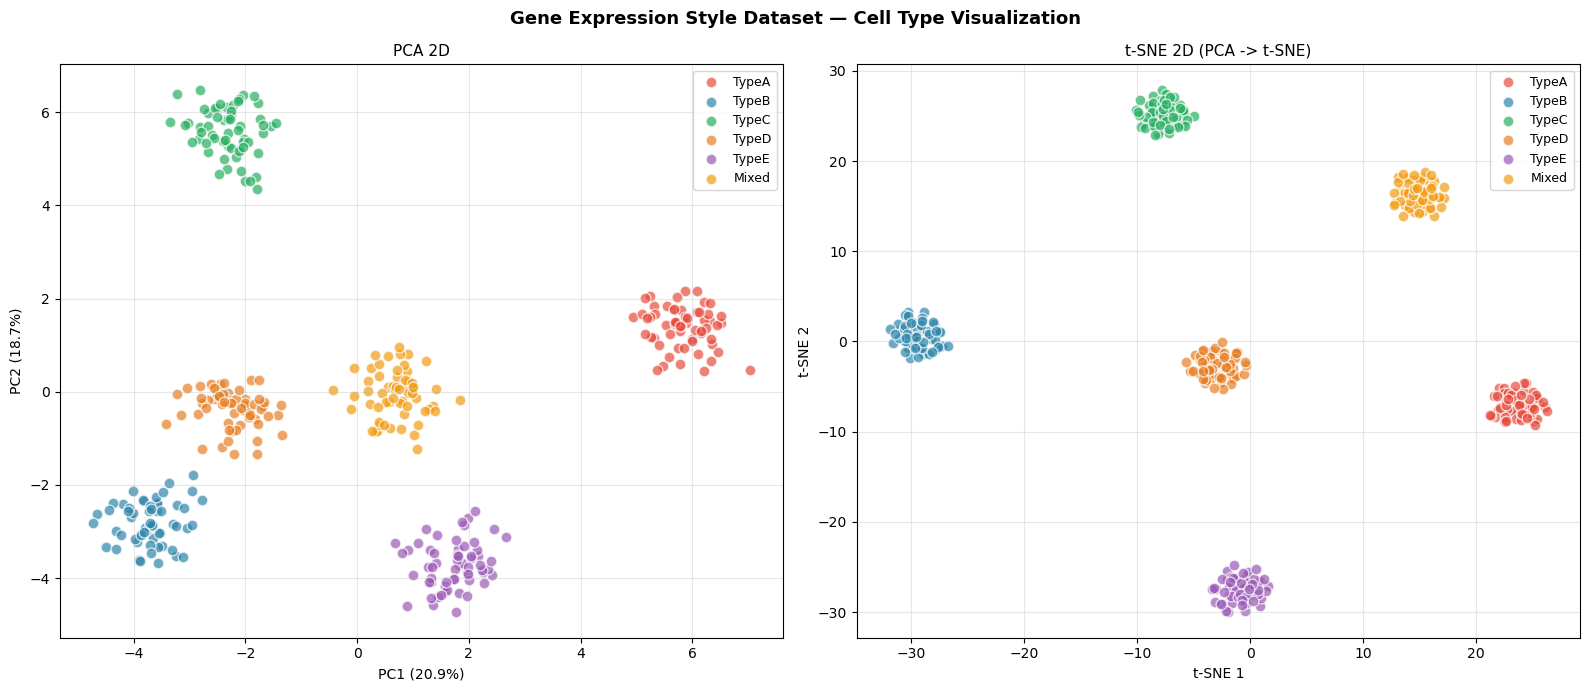

In [10]:
np.random.seed(42)
n_cells    = 360
n_genes    = 50
n_types    = 6
cell_names = ['TypeA','TypeB','TypeC','TypeD','TypeE','Mixed']

# Each cell type has a distinct gene expression signature
base = np.random.randn(n_types, n_genes) * 0.5
for k in range(5):
    base[k, k*10:(k+1)*10] += 5.0
base[5, [0,10,20,30,40]] += 4.0  # mixed type

X_rw, y_rw = [], []
n_per = n_cells // n_types
for k in range(n_types):
    X_rw.append(base[k] + np.random.randn(n_per, n_genes) * 1.0)
    y_rw.extend([k]*n_per)

X_rw = np.vstack(X_rw)
y_rw = np.array(y_rw)
print(f'Dataset shape : {X_rw.shape}')
print(f'Cell counts   : {np.bincount(y_rw)}')

X_rw_sc   = StandardScaler().fit_transform(X_rw)
X_rw_pca  = PCA(n_components=20, random_state=42).fit_transform(X_rw_sc)
X_rw_tsne = make_tsne(perplexity=25, n_iterations=1000).fit_transform(X_rw_pca)
X_rw_pca2 = PCA(n_components=2).fit_transform(X_rw_sc)
evr_rw    = PCA(n_components=2).fit(X_rw_sc).explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, X_2d, title, xl, yl in zip(
    axes,
    [X_rw_pca2, X_rw_tsne],
    ['PCA 2D', 't-SNE 2D (PCA -> t-SNE)'],
    [f'PC1 ({evr_rw[0]*100:.1f}%)', 't-SNE 1'],
    [f'PC2 ({evr_rw[1]*100:.1f}%)', 't-SNE 2']
):
    for k, lbl in enumerate(cell_names):
        mask = y_rw == k
        ax.scatter(X_2d[mask,0], X_2d[mask,1],
                   color=CLUSTER_COLORS[k], s=60, alpha=0.7,
                   edgecolors='white', label=lbl)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Gene Expression Style Dataset — Cell Type Visualization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Limitations & Best Practices

In [11]:
print('=== t-SNE LIMITATIONS ===')
print()
print('1. DISTANCES NOT MEANINGFUL')
print('   Cluster sizes and inter-cluster distances have no numeric interpretation.')
print()
print('2. VISUALIZATION ONLY')
print('   No transform() method -> cannot embed new/unseen data points.')
print()
print('3. STOCHASTIC')
print('   Results vary run to run. Use init="pca" + random_state to stabilize.')
print()
print('4. SLOW ON LARGE DATA')
print('   O(n^2) naive, O(n log n) with Barnes-Hut approximation.')
print('   For n > 10k: PCA to 50 dims first.')
print('   For n > 100k: use UMAP instead.')
print()
print('5. HYPERPARAMETER SENSITIVE')
print('   Always try multiple perplexity values (5, 15, 30, 50).')
print()
print('=== BEST PRACTICES ===')
steps = [
    ('Step 1', 'StandardScaler before t-SNE — required'),
    ('Step 2', 'PCA to ~50 dims first for speed'),
    ('Step 3', 'Use init="pca" + random_state for reproducibility'),
    ('Step 4', 'Try perplexity in [5, 15, 30, 50]'),
    ('Step 5', 'Use n_iter/max_iter >= 1000'),
    ('Step 6', 'Never interpret distances or cluster sizes quantitatively'),
    ('Step 7', 'Use for visualization only, not downstream ML'),
]
for step, tip in steps:
    print(f'  {step}: {tip}')
print()
print('=== t-SNE vs UMAP ===')
rows = [
    ('Speed',          'Slow O(n log n)',      'Fast O(n)'),
    ('Global struct',  'Often distorted',      'Better preserved'),
    ('New data',       'No transform()',        'Has transform()'),
    ('Stability',      'Use random_state',     'More stable'),
    ('Parameters',     'perplexity, n_iter',   'n_neighbors, min_dist'),
    ('Library',        'sklearn built-in',      'pip install umap-learn'),
]
print(f'  {"Property":<16} {"t-SNE":<25} {"UMAP"}')
print('  ' + '-'*60)
for prop, t, u in rows:
    print(f'  {prop:<16} {t:<25} {u}')

=== t-SNE LIMITATIONS ===

1. DISTANCES NOT MEANINGFUL
   Cluster sizes and inter-cluster distances have no numeric interpretation.

2. VISUALIZATION ONLY
   No transform() method -> cannot embed new/unseen data points.

3. STOCHASTIC
   Results vary run to run. Use init="pca" + random_state to stabilize.

4. SLOW ON LARGE DATA
   O(n^2) naive, O(n log n) with Barnes-Hut approximation.
   For n > 10k: PCA to 50 dims first.
   For n > 100k: use UMAP instead.

5. HYPERPARAMETER SENSITIVE
   Always try multiple perplexity values (5, 15, 30, 50).

=== BEST PRACTICES ===
  Step 1: StandardScaler before t-SNE — required
  Step 2: PCA to ~50 dims first for speed
  Step 3: Use init="pca" + random_state for reproducibility
  Step 4: Try perplexity in [5, 15, 30, 50]
  Step 5: Use n_iter/max_iter >= 1000
  Step 6: Never interpret distances or cluster sizes quantitatively
  Step 7: Use for visualization only, not downstream ML

=== t-SNE vs UMAP ===
  Property         t-SNE                     UM

## 11. Final Summary & Key Takeaways

In [12]:
print('=' * 65)
print('               t-SNE - KEY TAKEAWAYS')
print('=' * 65)
takeaways = [
    ('Purpose',         'Visualization of high-dimensional data in 2D/3D only'),
    ('Non-linear',      'Preserves local neighborhoods unlike linear PCA'),
    ('perplexity',      'Effective neighbors; try 5-50; < n_samples/3 rule'),
    ('max_iter',        'Use >= 1000; sklearn >= 1.5 renamed n_iter -> max_iter'),
    ('init=pca',        'More reproducible and faster than random init'),
    ('PCA first',       'PCA to ~50 dims before t-SNE for speed'),
    ('Scaling',         'ALWAYS StandardScaler before t-SNE'),
    ('No transform()',  'Cannot embed new data — visualization only'),
    ('Distances',       'Cluster size and inter-cluster distance NOT meaningful'),
    ('random_state',    'Always set for reproducibility'),
    ('Validation',      'Overlay cluster labels on t-SNE map to validate'),
    ('Large data',      'n > 50k -> use UMAP instead of t-SNE'),
    ('vs PCA',          'PCA: fast, global, preprocessing; t-SNE: viz, local, slow'),
    ('vs UMAP',         'UMAP: faster, global preserved, has transform()'),
    ('Error fix',       'LOKY error -> set os.environ["LOKY_MAX_CPU_COUNT"]="4"'),
]
for topic, detail in takeaways:
    print(f'  OK  {topic:<18}  ->  {detail}')
print('=' * 65)

               t-SNE - KEY TAKEAWAYS
  OK  Purpose             ->  Visualization of high-dimensional data in 2D/3D only
  OK  Non-linear          ->  Preserves local neighborhoods unlike linear PCA
  OK  perplexity          ->  Effective neighbors; try 5-50; < n_samples/3 rule
  OK  max_iter            ->  Use >= 1000; sklearn >= 1.5 renamed n_iter -> max_iter
  OK  init=pca            ->  More reproducible and faster than random init
  OK  PCA first           ->  PCA to ~50 dims before t-SNE for speed
  OK  Scaling             ->  ALWAYS StandardScaler before t-SNE
  OK  No transform()      ->  Cannot embed new data — visualization only
  OK  Distances           ->  Cluster size and inter-cluster distance NOT meaningful
  OK  random_state        ->  Always set for reproducibility
  OK  Validation          ->  Overlay cluster labels on t-SNE map to validate
  OK  Large data          ->  n > 50k -> use UMAP instead of t-SNE
  OK  vs PCA              ->  PCA: fast, global, preprocessing;

---
## Practice Exercises

1. **Sweep perplexity** from 2 to 100 and plot silhouette score of t-SNE embedding.
2. **Compare PCA+t-SNE vs raw t-SNE** on speed and embedding quality.
3. **Try UMAP** — `pip install umap-learn`, apply to gene expression dataset.
4. **Overlay K-Means boundaries** on the t-SNE map using `plt.contour`.
5. **Run t-SNE 5 times** with different seeds — measure cluster layout stability.
6. **Apply to text** — TF-IDF vectorize, PCA to 50, then t-SNE to 2D.

---
*Notebook created for the ML Repository — t-SNE module.*